A note about using generative AI to assist with debugging and code suggestions:

We used Gemini to identify errors in our code and used its suggestions to fix them.

In [ ]:
#mounting google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
#syncing to github

%cd /content/drive/MyDrive/LTPythonCode
!git clone https://github.com/KyleAdams26/LTCode

/content/drive/MyDrive/LTPythonCode
Cloning into 'LTCode'...
remote: Enumerating objects: 74, done.
remote: Counting objects: 100% (74/74), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 74 (delta 36), reused 22 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (74/74), 22.15 KiB | 872.00 KiB/s, done.
Resolving deltas: 100% (36/36), done.


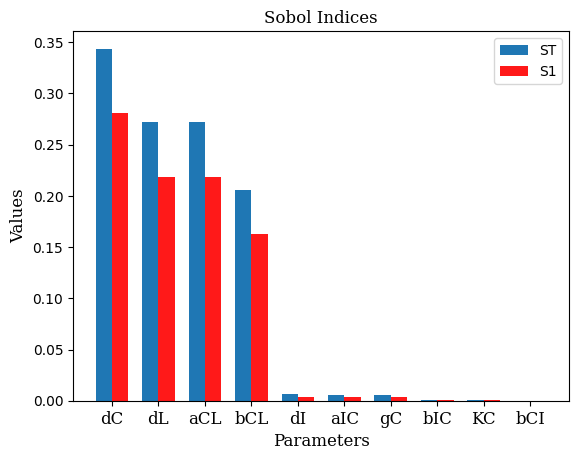

In [ ]:
#plotting Sobol Indices

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

#reading in data from matlab SA results
SA_values = pd.read_csv('/content/drive/MyDrive/SAVALUES.txt', sep = ',', header=None, names=['S1', 'ST'])
SA_values = SA_values.assign(param = ['params', 'lL', 'dA', 'sR', 'dR', 'aIR', 'bIR', 'aCI', 'bCI', 'aHI', 'bHI', 'lC', 'gC', 'KC',
                                      'aIC', 'bIC', 'lH', 'gH', 'KH', 'aIH', 'bIH', 'lR', 'dI', 'aHC', 'bHC', 'dC', 'aAH',
                                      'bAH', 'aRA', 'bRA', 'aIRA', 'bIRA', 'dH', 'dL', 'aCL', 'bCL'])

#deleting first entry which is column title, then sorting by ST
SA_values = SA_values.iloc[1:]
# Convert the 'ST' column to numeric, handling potential errors (sorting wasn't working without this step)
SA_values['ST'] = pd.to_numeric(SA_values['ST'], errors='coerce')
SA_values = SA_values.sort_values('ST', ascending=False)
SA_values = SA_values.head(10) # This line selects the top 10 influential parameters

categories = ['ST', 'S1']
ST = SA_values['ST']
S1 = SA_values['S1']

#convert to float to avoid potential errors (graph wasn't working without this)
ST = ST.astype(float)
S1 = S1.astype(float)


#x axis is parameter names
x = SA_values['param']
x_pos = np.arange(len(x)) #need for bar placement


# Set the width of each bar
bar_width = 0.35

# Create the figure and axes
fig, ax = plt.subplots()

# Plot the ST and S1 bars
rectsST = ax.bar(x_pos - bar_width/2, ST, bar_width, label='ST')
rectsS1 = ax.bar(x_pos + bar_width/2, S1, bar_width, label='S1', color = 'red', alpha = 0.9)

#Adding labels, title, and legend
#Updating xticklabels to reflect the actual param names instead of just 'ST' and 'S1'
font = fm.FontProperties(family='serif', size=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(x, fontproperties = font)
ax.set_xlabel('Parameters', fontproperties=font)
ax.set_ylabel('Values', fontproperties=font)
ax.set_title('Sobol Indices', fontproperties=font)
ax.legend(prop=font)
ax.legend()

# Show the plot
plt.show()

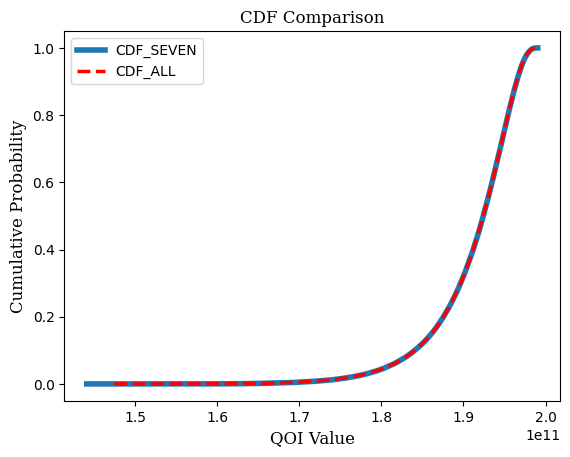

In [ ]:
#this block plots the CDFs of QOI distributions when
#sampling with all parameters varying and then the 7
#most influential parameters varying

from re import S
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from scipy import stats
%matplotlib inline


# loading SA files
file_path_ALL = '/content/drive/MyDrive/CopyALLCELLS.txt'
file_path_SEVEN = '/content/drive/MyDrive/SEVENCELLS.txt'

ALLCELLS = np.random.choice(np.loadtxt(file_path_ALL, delimiter=','), 900000, replace=True) #taking subset of ALLCELLS so length matches SEVENCELLS
SEVENCELLS = np.loadtxt(file_path_SEVEN, delimiter=',')

# getting data of the histogram
countALL, bins_count = np.histogram(ALLCELLS, bins=10000)
countSEVEN, bins_count1 = np.histogram(SEVENCELLS, bins=10000)

# finding the PDF of the histogram using count values
pdfALL = countALL / sum(ALLCELLS)
pdfSEVEN = countSEVEN / sum(SEVENCELLS)

# using numpy np.cumsum to calculate the CDF
cdfALL = np.cumsum(pdfALL) / sum(pdfALL)
cdfSEVEN = np.cumsum(pdfSEVEN) / sum(pdfSEVEN)



# plotting CDFs
plt.plot(bins_count1[1:], cdfSEVEN, label="CDF_SEVEN", linewidth = 4)
plt.plot(bins_count[1:], cdfALL, color="red", label="CDF_ALL", linewidth = 2.5, linestyle='--',)
font = fm.FontProperties(family='serif', size=12)
plt.xlabel('QOI Value', fontproperties=font)
plt.ylabel('Cumulative Probability', fontproperties=font)
plt.title('CDF Comparison', fontproperties=font)
plt.legend()



Text(0, 0.5, 'Frequency')

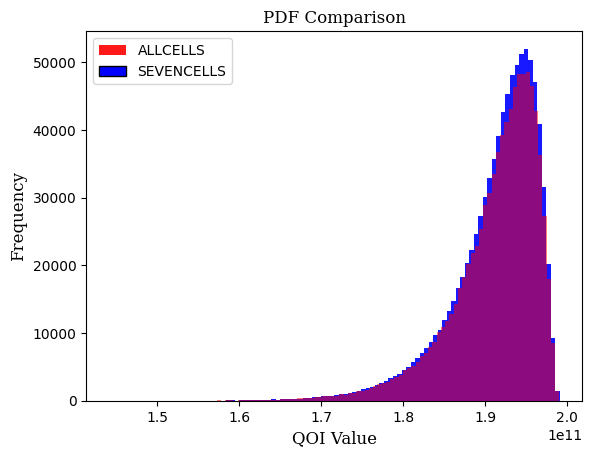

In [ ]:
import matplotlib.patches as mpatches

#plotting PDFs
ALLCELLS = np.random.choice(np.loadtxt(file_path_ALL, delimiter=','), 900000, replace=True) #taking subset of ALLCELLS so length matches FIVECELLS
SEVENCELLS = np.loadtxt(file_path_SEVEN, delimiter=',')

plt.hist(SEVENCELLS, bins=100, alpha = 0.9, color = 'blue')
plt.hist(ALLCELLS, bins=100, color = 'red', alpha = 0.5)


# Creating custom legend handles
all_cells_handle = mpatches.Patch(facecolor='red', alpha = 0.9, label='ALLCELLS')
seven_cells_handle = mpatches.Patch(facecolor='blue', edgecolor='black', label='SEVENCELLS', alpha=1)

# Updating legend
plt.legend(handles=[all_cells_handle, seven_cells_handle])
font = fm.FontProperties(family='serif', size=12)
plt.title("PDF Comparison", fontproperties = font)
plt.xlabel("QOI Value", fontproperties = font)
plt.ylabel("Frequency", fontproperties = font)



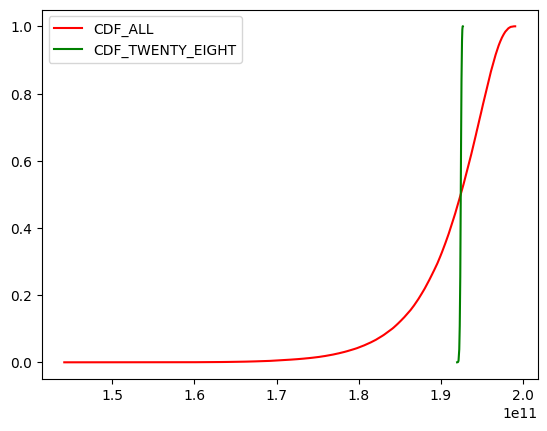

Text(0, 0.5, 'Frequency')

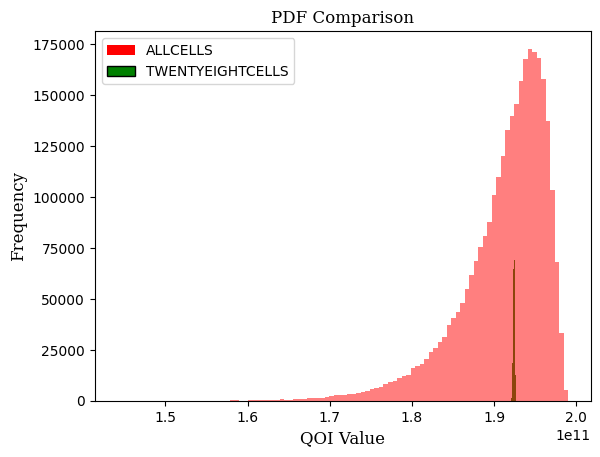

In [ ]:
#this block plots the CDFs and PDFs of QOI distributions
#when sampling with all parameters varying and then the
#28 least influential parameters

from re import S
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from scipy import stats
%matplotlib inline


# loading SA files



ALLCELLS = np.random.choice(np.loadtxt(file_path_ALL, delimiter=','), 3000000, replace=True) #taking subset of ALLCELLS so length matches TWENTYEIGHTCELLS
file_path_TWENTYEIGHT = '/content/drive/MyDrive/TWENTYEIGHTCELLS.txt'
TWENTYEIGHTCELLS = np.loadtxt(file_path_TWENTYEIGHT, delimiter=',')


# getting data of the histogram
countALL, bins_count = np.histogram(ALLCELLS, bins=10000)
countTWENTYEIGHT, bins_count1 = np.histogram(TWENTYEIGHTCELLS, bins=10000)

# finding the PDF of the histogram using count values
pdfALL = countALL / sum(ALLCELLS)
pdfTWENTYEIGHT = countTWENTYEIGHT / sum(TWENTYEIGHTCELLS)

# using numpy np.cumsum to calculate the CDF
# We can also find using the PDF values by looping and adding
cdfALL = np.cumsum(pdfALL) / sum(pdfALL)
cdfTWENTYEIGHT = np.cumsum(pdfTWENTYEIGHT) / sum(pdfTWENTYEIGHT)

# plotting CDFs
plt.plot(bins_count[1:], cdfALL, color="red", label="CDF_ALL")
plt.plot(bins_count1[1:], cdfTWENTYEIGHT, color ='green', label="CDF_TWENTY_EIGHT")
plt.legend()
plt.show()

#plotting PDFs
plt.hist(TWENTYEIGHTCELLS, bins=100, alpha = 0.9, color = 'green')
plt.hist(ALLCELLS, bins=100, color = 'red', alpha = 0.5)
plt.xlabel('QOI Value', fontproperties=font)
plt.ylabel('Cumulative Probability', fontproperties=font)
plt.title('CDF Comparison', fontproperties=font)
plt.legend()



# Creating custom legend handles
all_cells_handle = mpatches.Patch(facecolor='red', alpha = 1, label='ALLCELLS')
twentyeight_cells_handle = mpatches.Patch(facecolor='green', edgecolor='black', label='TWENTYEIGHTCELLS', alpha=1)

# Updating legend
plt.legend(handles=[all_cells_handle, twentyeight_cells_handle])
font = fm.FontProperties(family='serif', size=12)
plt.title("PDF Comparison", fontproperties = font)
plt.xlabel("QOI Value", fontproperties = font)
plt.ylabel("Frequency", fontproperties = font)



In [7]:
%cd /content/drive/MyDrive/LTPythonCode/LTCode

/content/drive/MyDrive/LTPythonCode/LTCode


In [8]:
!git add .

In [ ]:
!git config --global user.email "adams.k@ufl.edu"
!git config --global user.name "KyleAdams26"

In [9]:
!git commit -m "adding plots from python"

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [ ]:
!git commit --amend

fatal: not a git repository (or any of the parent directories): .git


In [10]:
!git push -u origin main

fatal: could not read Username for 'https://github.com': No such device or address
